# Evaluation Definition

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib

import matplotlib.pyplot as plt



from typing import Sequence
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score


def evaluate_ganomaly(
    netg,
    test_loader,
    *,
    bona_label_value: int = 1,
    device: str | torch.device | None = None,
    n_display: int = 3,
    seed: int = 0,
    plot_scaled: bool = True,
    nbins: int = 100,
    plot_roc: bool = True,
    lower_score_is_anomalous: bool = False      # ← choose convention here
):
    """
    Evaluate *single-decoder* GANomaly model.
    Plots histograms, ROC; returns scores, labels, AUC, best-F1 & best-ACC.

    Parameters
    ----------
    lower_score_is_anomalous : bool, optional
        True  → anomaly ⇔ score ≤ threshold
        False → anomaly ⇔ score ≥ threshold
    """
    # ──────────────────────── 1. forward pass ────────────────────────────
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    netg = netg.to(device).eval()

    all_scores, all_labels, all_x, all_xhat = [], [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            x_hat, z_i, z_o = netg(x)

            l_rec = F.l1_loss(x_hat, x, reduction="none").view(x.size(0), -1).sum(1)
            l_enc = torch.norm((z_i - z_o).view(z_i.size(0), -1), p=2, dim=1)

            score = l_enc.cpu()                 # or (l_rec + l_enc)
            all_scores.append(score)
            all_labels.append(y)
            all_x.append(x.cpu())
            all_xhat.append(x_hat.cpu())

    scores = torch.cat(all_scores).numpy()
    labels = torch.cat(all_labels).numpy()
    xs     = torch.cat(all_x).numpy()
    xhats  = torch.cat(all_xhat).numpy()

    bona_mask = labels == bona_label_value
    anom_mask = ~bona_mask

    # ──────────────────────── 2. histograms ──────────────────────────────
    lo, hi = np.percentile(scores, [1, 100])
    plt.figure()
    plt.hist(scores[bona_mask], bins=nbins, alpha=0.6, label="Bona-fide", range=(lo, hi))
    plt.hist(scores[anom_mask], bins=nbins, alpha=0.6, label="Anomalous", range=(lo, hi))
    plt.xlabel("Anomaly score")
    plt.ylabel("Count")
    plt.title("Score distribution")
    plt.legend(); plt.show()

    if plot_scaled:
        s_min, s_max = scores.min(), scores.max()
        s_scaled = (scores - s_min)/(s_max - s_min) if s_max != s_min else np.zeros_like(scores)
        plt.figure()
        plt.hist(s_scaled[bona_mask], bins=nbins, alpha=0.6, label="Normal",   color="#c77d7d")
        plt.hist(s_scaled[anom_mask], bins=nbins, alpha=0.6, label="Abnormal", color="#6487a8")
        plt.xlabel("Min–max scaled score")
        plt.ylabel("Count")
        plt.title("Scaled score distribution")
        plt.legend(); plt.show()

    # ──────────────────────── 3. ROC / AUC ───────────────────────────────
    y_true = (~bona_mask).astype(int)              # anomaly = 1
    roc_scores = -scores if lower_score_is_anomalous else scores
    fpr, tpr, roc_thresh = roc_curve(y_true, roc_scores)
    roc_auc = auc(fpr, tpr)

    if plot_roc:
        plt.figure()
        plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False-positive rate"); plt.ylabel("True-positive rate")
        plt.title("ROC curve"); plt.legend(); plt.grid(ls=":"); plt.show()

    # ───────────── 4. sweep thresholds → best F1 / ACC ───────────────────
    best_f1  = {"threshold": None, "score": -1.0}
    best_acc = {"threshold": None, "score": -1.0}

    for thr_s in np.unique(roc_thresh):
        if np.isinf(thr_s):                # skip +inf appended by roc_curve
            continue
        # Map ROC-space threshold back to original score space
        thr = -thr_s if lower_score_is_anomalous else thr_s

        if lower_score_is_anomalous:
            y_pred = (scores <= thr).astype(int)
        else:
            y_pred = (scores >= thr).astype(int)

        f1  = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)

        if f1 > best_f1["score"]:
            best_f1 = {"threshold": float(thr), "score": float(f1)}
        if acc > best_acc["score"]:
            best_acc = {"threshold": float(thr), "score": float(acc)}

    print(f"AUC          : {roc_auc:.4f}")
    arrow = "≤" if lower_score_is_anomalous else "≥"
    print(f"Best F1      : {best_f1['score']:.4f}  @ thr {arrow} {best_f1['threshold']:.4f}")
    print(f"Best Accuracy: {best_acc['score']:.4f}  @ thr {arrow} {best_acc['threshold']:.4f}")

    # ──────────────────────── 5. reconstructions ────────────────────────
    rng = np.random.default_rng(seed)
    bona_idxs = rng.choice(np.where(bona_mask)[0], size=min(n_display, bona_mask.sum()), replace=False)
    anom_idxs = rng.choice(np.where(anom_mask)[0], size=min(n_display, anom_mask.sum()), replace=False)

    def _plot_pairs(idxs: Sequence[int], title: str):
        rows, cols = len(idxs), 2
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3), constrained_layout=True)
        axes = axes[None, :] if rows == 1 else axes
        fig.suptitle(title, fontsize=14)
        for r, idx in enumerate(idxs):
            axes[r, 0].imshow(xs[idx, 0],  origin="lower", cmap="viridis"); axes[r, 0].axis("off")
            axes[r, 0].set_title(f"Input idx={idx}")
            axes[r, 1].imshow(xhats[idx, 0], origin="lower", cmap="viridis"); axes[r, 1].axis("off")
            axes[r, 1].set_title("Reconstruction")
        plt.show()

    if bona_idxs.size: _plot_pairs(bona_idxs, "Bona-fide samples")
    if anom_idxs.size: _plot_pairs(anom_idxs, "Anomalous samples")

    # ──────────────────────── 6. return ─────────────────────────────────
    return scores, labels, roc_auc, best_f1, best_acc


In [3]:
import os, numpy as np, torch
from torch.utils.data import Dataset, DataLoader

class AggregatedPairDataset(Dataset):

    def __init__(self, dir_path: str, *, isize: int = 64):
        self.samples = []
        for fname, lbl in (('fake.npy', 1), ('real.npy', 0)):
            p = os.path.join(dir_path, fname)
            arr = np.load(p).astype('float32')          # (N,1,H,W)
            if arr.ndim != 4 or arr.shape[2:] != (isize, isize):
                raise ValueError(
                    f"{fname}: expected (N,1,{isize},{isize}), got {arr.shape}"
                )
            # Push each item with its class label
            for spec in arr:
                self.samples.append((spec, lbl))
        # shuffle once so classes are mixed (keep deterministic if needed)
        np.random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        spec, lbl = self.samples[idx]
        return torch.from_numpy(spec), torch.tensor(lbl, dtype=torch.long)

In [4]:
import argparse
def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser("Train single-decoder GANomaly")

    # ---------- data ----------
    g_data = p.add_argument_group("data")
    g_data.add_argument("--data_file", type=str, default="ResData/wavefake128_2048split/train/fake",
                        help="aggregated (N,C,H,W) .npy or dir of such")
    g_data.add_argument("--data_root", type=str, default=None,
                        help="folder of individual (C,H,W) .npy files")
    g_data.add_argument("--isize", type=int, default=128, help="image H×W")
    g_data.add_argument("--nc",    type=int, default=1,   help="#channels")

    # ---------- model ----------
    g_model = p.add_argument_group("model")
    g_model.add_argument("--nz",          type=int, default=128, help="latent dim")
    g_model.add_argument("--ngf",         type=int, default=64, help="#gen filters")
    g_model.add_argument("--ndf",         type=int, default=64, help="#disc filters")
    g_model.add_argument("--extralayers", type=int, default=0,
                         help="extra conv layers in G/D (DCGAN style)")
    g_model.add_argument("--ngpu",        type=int, default=1,
                         help="#GPUs for DataParallel (set 1 for single-GPU)")

    # ---------- training ----------
    g_train = p.add_argument_group("training")
    g_train.add_argument("--batchSize", type=int, default=32)
    g_train.add_argument("--niter",     type=int, default=3000, help="#epochs")
    g_train.add_argument("--lr",        type=float, default=2e-3)
    g_train.add_argument("--beta1",     type=float, default=0.5)
    g_train.add_argument("--tb_freq",   type=int, default=200,
                         help="TensorBoard scalar period (iters)")
    g_train.add_argument("--save_freq", type=int, default=10,
                         help="epochs between light ckpts")

    # ---------- misc ----------
    g_misc = p.add_argument_group("misc")
    g_misc.add_argument("--outf",   type=str, default="./output_tradgan_tuned",
                        help="root for logs/ckpts")
    g_misc.add_argument("--name",   type=str, default="128singleFakeWavefake")
    g_misc.add_argument("--device", type=str, default="cuda:0")
    g_misc.add_argument("--manualseed", type=int, default=None)
    g_misc.add_argument("--resume",     type=str, default=None,
                        help="resume from full ckpt")
    g_misc.add_argument("--load_light", type=str, default=None,
                        help="initialise weights from light ckpt")
    
    g_model.add_argument("--w_adv", type=float, default=1.0,
                     help="weight W_adv in Eq. 12")
    g_model.add_argument("--w_con", type=float, default=30.0,
                        help="weight W_con in Eq. 12")
    g_model.add_argument("--w_enc", type=float, default=1.0,
                        help="weight W_enc in Eq. 12")
    g_model.add_argument("--lambdaGP", type=float, default=10.0,)
    g_train.add_argument("--n_critic",  type=int, default=5,
                         help="#discriminator updates per generator update")


    return p

In [5]:
from RES_GANomaly_model import RES_Ganomaly
def build_netg() -> torch.nn.Module:
    """
    Re-create the generator architecture exactly as in training,
    but with random weights.  *No heavy data loaders allocated.*  
    """
    # 1) Rebuild the same argparse.Namespace (`opt`) that you used to train.
    #    Here I follow the values you showed; adjust if your training config differs.
    opt = build_parser().parse_args([])   # start from all-default CLI
    opt.device = "cpu"                    # keep on CPU; we'll .to(device) later
    opt.isize  = 128
    opt.nz     = 64
    opt.nc     = 1
    opt.w_adv  = 1.0
    opt.w_con  = 50.0
    opt.w_enc  = 1.0

    # 2) Ganomaly's ctor expects a dataloader dict.  
    #    Give it a *tiny* dummy loader so memory stays minimal.
    dummy_ds      = torch.utils.data.TensorDataset(
        torch.zeros(1, 1, opt.isize, opt.isize)
    )
    dummy_loader  = DataLoader(dummy_ds, batch_size=1)
    dl_dict = {"train": [dummy_loader]}

    model = RES_Ganomaly(opt, dl_dict)
    return model.netg

In [6]:
import os, re, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, f1_score, accuracy_score

def evaluate_and_plot_epochs_efficient_model(
    model,
    test_loader,
    checkpoints_dir: str,
    bona_label_value: int = 1,
    device: str = "cpu",
    lower_score_is_anomalous: bool = False
):
    """
    model        : your RES_Ganomaly instance (with .load(path) and .netg)
    test_loader  : DataLoader over AggregatedPairDataset
    checkpoints_dir : folder containing checkpoint_epochXXX.pth
    bona_label_value: label of your bona-fide class (0 or 1)
    device       : e.g. "cuda:0"
    lower_score_is_anomalous: if True, treat score ≤ thr as anomaly
    """
    # 1) send model.netg to device once
    model.netg.to(device).eval()

    # 2) find & sort checkpoints
    paths = sorted(
        glob.glob(os.path.join(checkpoints_dir, "checkpoint_epoch*.pth")),
        key=lambda p: int(re.search(r"checkpoint_epoch(\d+)\.pth", os.path.basename(p)).group(1))
    )

    # 3) extract labels once
    labels = np.concatenate([y.numpy() for _, y in test_loader])
    N = labels.shape[0]
    y_true = (~(labels == bona_label_value)).astype(int)

    # 4) containers
    epochs, avg_real, avg_fake, f1s, ths, accs = [], [], [], [], [], []

    # 5) epoch loop
    for ckpt in paths:
        ep = int(re.search(r"checkpoint_epoch(\d+)\.pth", os.path.basename(ckpt)).group(1))

        # load weights into model
        model.load(ckpt, strict=False)
        torch.cuda.empty_cache()

        # allocate scores array
        scores = np.empty(N, dtype=np.float32)
        idx = 0

        with torch.no_grad():
            for x, _ in test_loader:
                b = x.size(0)
                x = x.to(device)
                x_hat, z_i, z_o = model.netg(x)

                sc = torch.norm((z_i - z_o).view(b, -1), p=2, dim=1).cpu().numpy()
                scores[idx:idx+b] = sc
                idx += b

                # free GPU memory
                del x, x_hat, z_i, z_o, sc

        # separate class averages
        bona_mask = labels == bona_label_value
        anom_mask = ~bona_mask
        avg_b = float(scores[bona_mask].mean()) if bona_mask.any() else float('nan')
        avg_a = float(scores[anom_mask].mean()) if anom_mask.any() else float('nan')

        # compute ROC-based metrics
        roc_in    = -scores if lower_score_is_anomalous else scores
        fpr, tpr, thr_roc = roc_curve(y_true, roc_in)

        best_f1 = {"score": -1.0, "thr": None}
        best_acc= {"score": -1.0}
        for t in np.unique(thr_roc):
            if np.isinf(t): continue
            thr = -t if lower_score_is_anomalous else t
            pred = (scores <= thr).astype(int) if lower_score_is_anomalous else (scores >= thr).astype(int)
            f1  = f1_score(y_true, pred, zero_division=0)
            acc = accuracy_score(y_true, pred)
            if f1 > best_f1["score"]:
                best_f1 = {"score": f1, "thr": thr}
            if acc > best_acc["score"]:
                best_acc["score"] = acc

        # record
        epochs.append(ep)
        avg_real.append(avg_b)
        avg_fake.append(avg_a)
        f1s.append(best_f1["score"])
        ths.append(best_f1["thr"])
        accs.append(best_acc["score"])

        print(f"Epoch {ep:4d} → avg_real={avg_b:.3f}, avg_fake={avg_a:.3f}, "
              f"F1={best_f1['score']:.3f}@{best_f1['thr']:.3f}, ACC={best_acc['score']:.3f}")

        del scores

        # 6) separate plots for each metric
    # Best F1 Score vs. Epoch
    plt.figure(figsize=(6,4))
    plt.plot(epochs, f1s, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Best F1 Score')
    plt.title('Best F1 Score vs. Epoch')
    plt.grid(ls=':')
    plt.tight_layout()
    plt.show()

    # Best Accuracy vs. Epoch
    plt.figure(figsize=(6,4))
    plt.plot(epochs, accs, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Best Accuracy')
    plt.title('Best Accuracy vs. Epoch')
    plt.grid(ls=':')
    plt.tight_layout()
    plt.show()

    # Average Score (Real) vs. Epoch
    plt.figure(figsize=(6,4))
    plt.plot(epochs, avg_real, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Average Score (Real)')
    plt.title('Average Score (Real) vs. Epoch')
    plt.grid(ls=':')
    plt.tight_layout()
    plt.show()

    # Average Score (Fake) vs. Epoch
    plt.figure(figsize=(6,4))
    plt.plot(epochs, avg_fake, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Average Score (Fake)')
    plt.title('Average Score (Fake) vs. Epoch')
    plt.grid(ls=':')
    plt.tight_layout()
    plt.show()

    # Threshold for Best F1 vs. Epoch
    plt.figure(figsize=(6,4))
    plt.plot(epochs, ths, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Threshold @ Best F1')
    plt.title('Threshold @ Best F1 vs. Epoch')
    plt.grid(ls=':')
    plt.tight_layout()
    plt.show()

    return {
        "epoch":     epochs,
        "avg_real":  avg_real,
        "avg_fake":  avg_fake,
        "best_f1":   f1s,
        "f1_thr":    ths,
        "best_acc":  accs
    }


# Train: Wavefake32

[Init] Networks on cuda:0
NetG_RES_GANomaly: Calculated ngf_deepest for decoder: 256
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime32/checkpoints/checkpoint_epoch590.pth (strict=False)


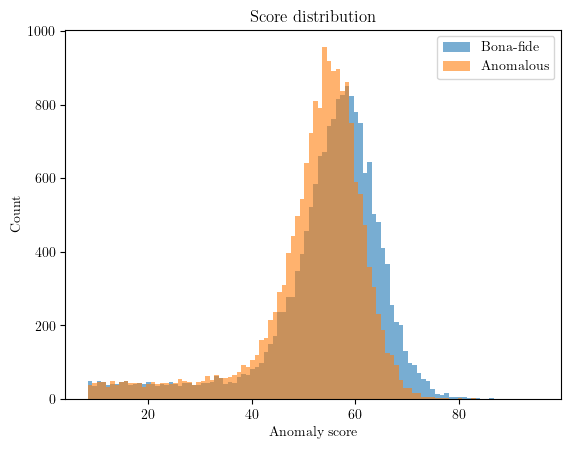

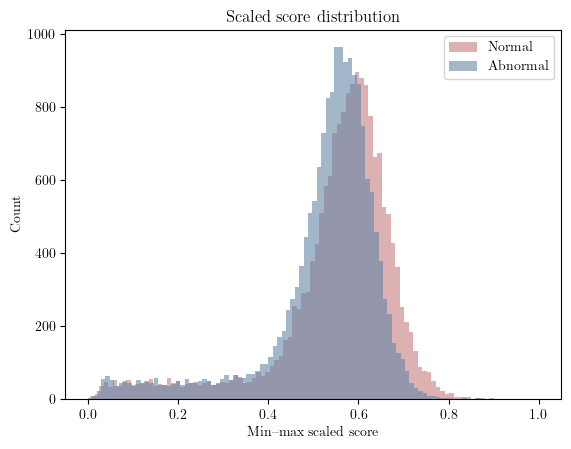

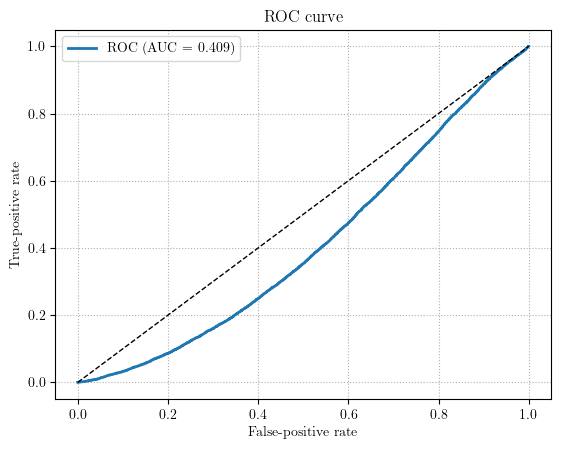

AUC          : 0.4093
Best F1      : 0.6667  @ thr ≥ 2.8450
Best Accuracy: 0.5001  @ thr ≥ 4.2503


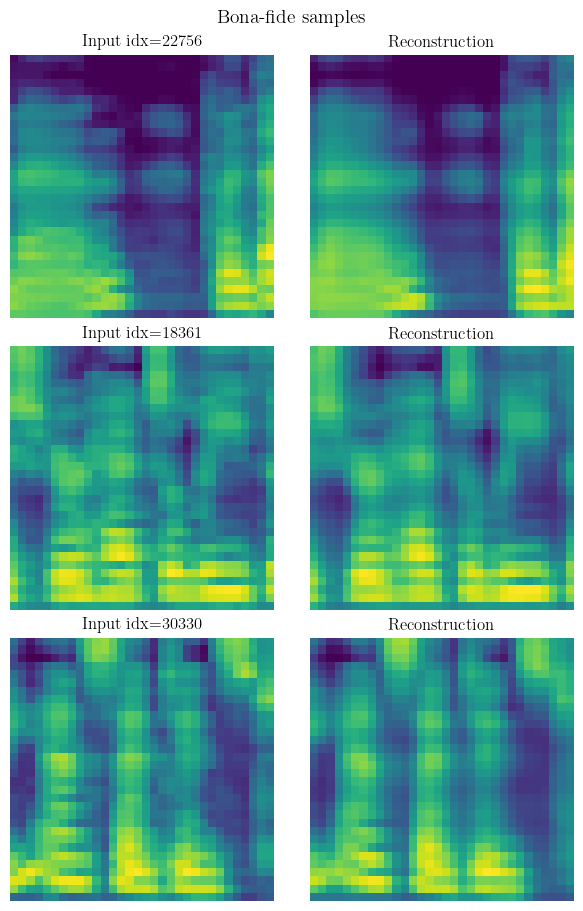

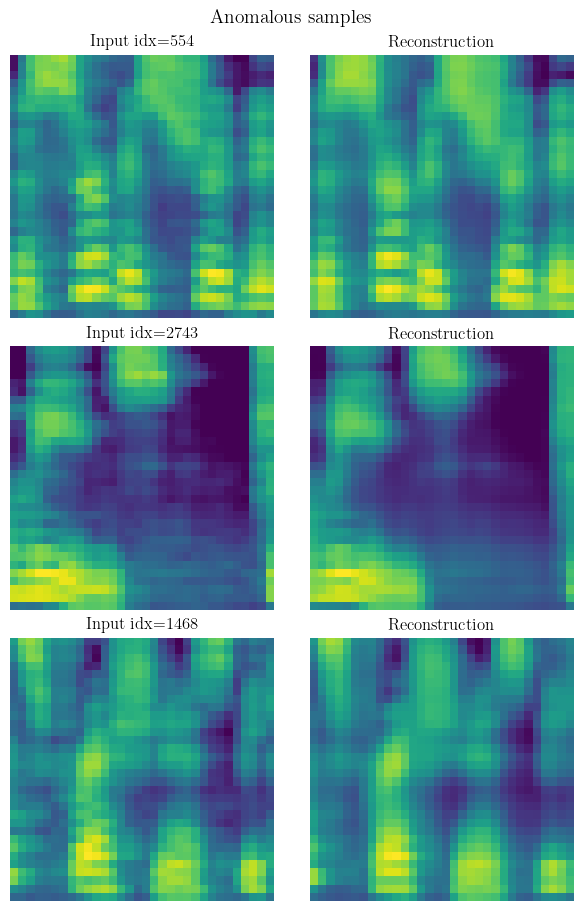

In [13]:
import argparse
import torch
from torch.utils.data import DataLoader
from RES_GANomaly_model import RES_Ganomaly

opt = build_parser().parse_args([])     # [] ⇒ no CLI → all defaults

opt.device  = "cuda:0"
opt.isize   = 32
opt.nc      = 1
opt.nz      = 100
opt.ngf     = 64
opt.ndf     = 128
opt.w_adv   = 1.0
opt.w_con   = 50.0
opt.w_enc   = 1.0
opt.manualseed = 1

dummy_ds = torch.utils.data.TensorDataset(torch.empty(1, 1, opt.isize, opt.isize))
dummy_loader = DataLoader(dummy_ds, batch_size=1)
dl_dict = {"train": [dummy_loader]}  

model = RES_Ganomaly(opt, dl_dict)        
ckpt_path = "/media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime32/checkpoints/checkpoint_epoch590.pth"
model.load(ckpt_path, strict=False)  
model.netg.eval()                    

test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/wavefake32_split/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

# ----------------------------------------------------------------------
# 5) Run evaluation (uses only model.netg)
# ----------------------------------------------------------------------
scores, labels, a, b, c = evaluate_ganomaly(model.netg,
                                   test_loader,
                                   bona_label_value=0,  # fake = bona-fide
                                   device=opt.device)


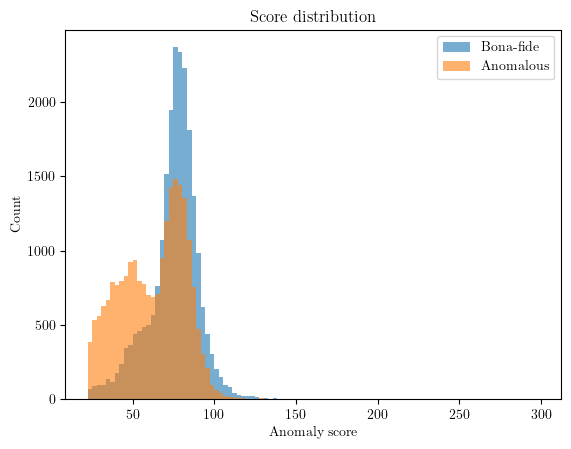

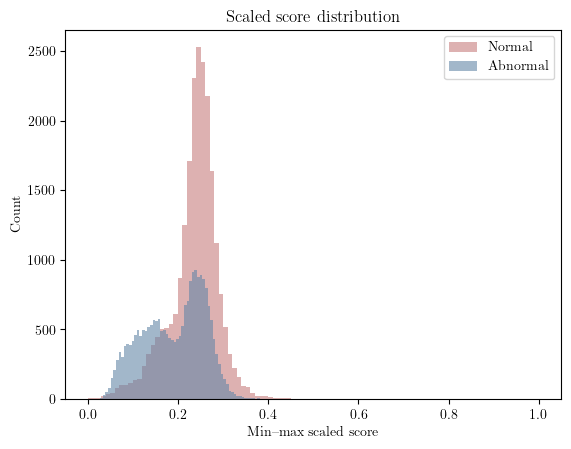

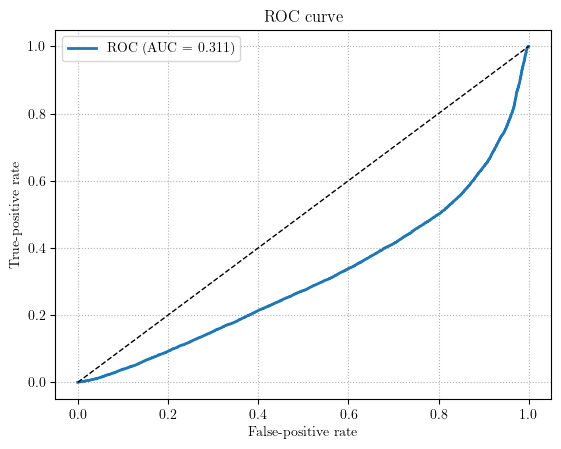

AUC          : 0.3113
Best F1      : 0.6669  @ thr ≥ 13.9340
Best Accuracy: 0.5005  @ thr ≥ 13.9340


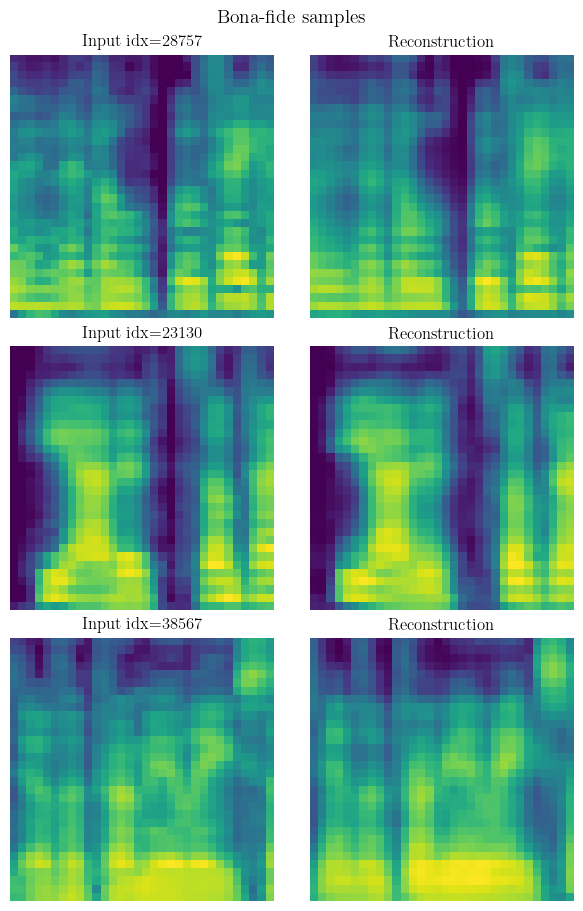

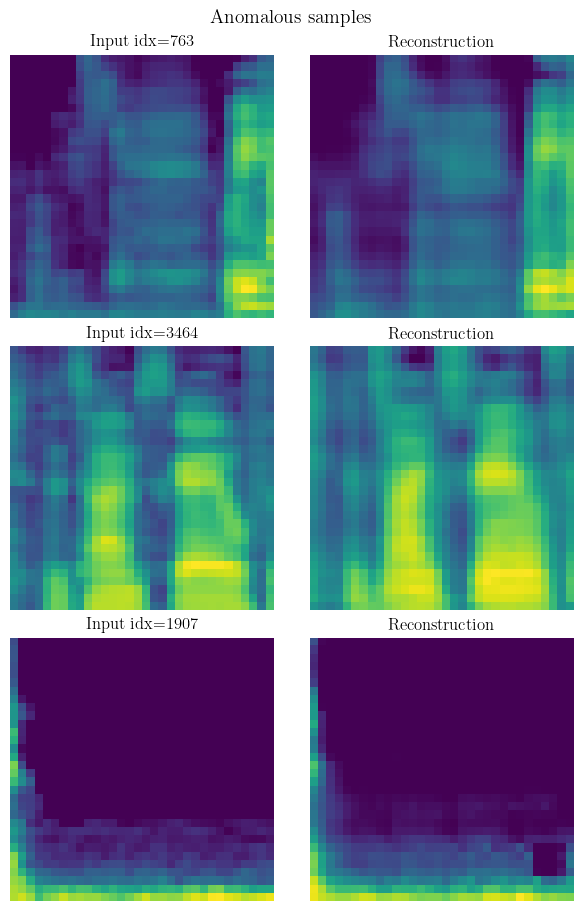

ValueError: too many values to unpack (expected 2)

In [15]:
test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/ASV32/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# ----------------------------------------------------------------------
# 5) Run evaluation (uses only model.netg)
# ----------------------------------------------------------------------
scores, labels = evaluate_ganomaly(model.netg,
                                   test_loader,
                                   bona_label_value=1,  # fake = bona-fide
                                   device=opt.device)


# Train: Wavefake128 (real)

[Init] Networks on cuda:0
NetG_RES_GANomaly: Calculated ngf_deepest for decoder: 1024
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch2800.pth (strict=False)


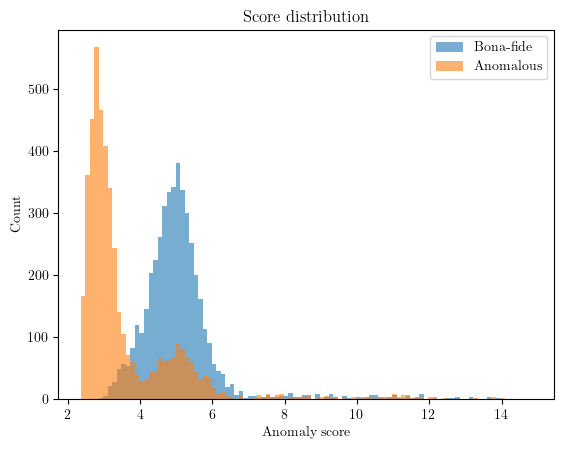

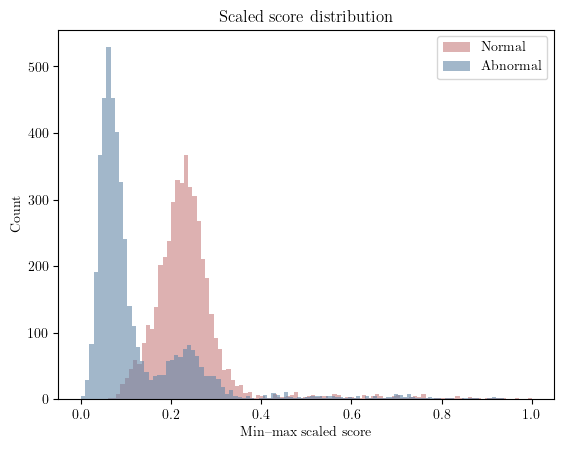

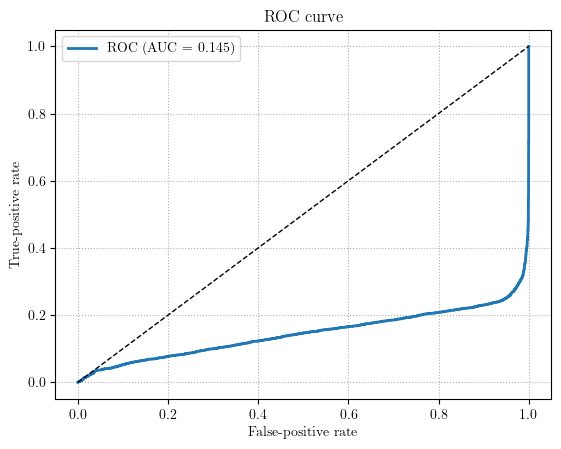

AUC          : 0.1453
Best F1      : 0.6667  @ thr ≥ 2.0224
Best Accuracy: 0.5001  @ thr ≥ 13.7320


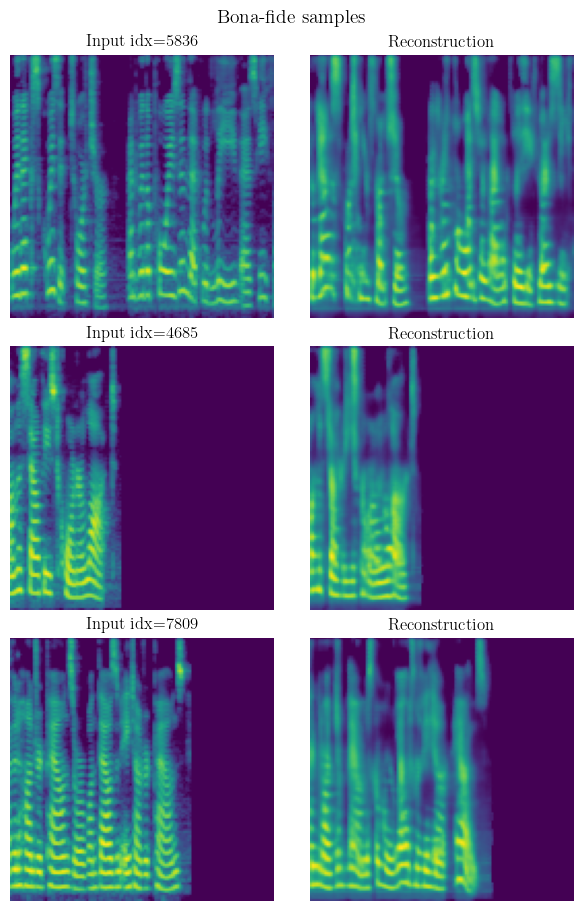

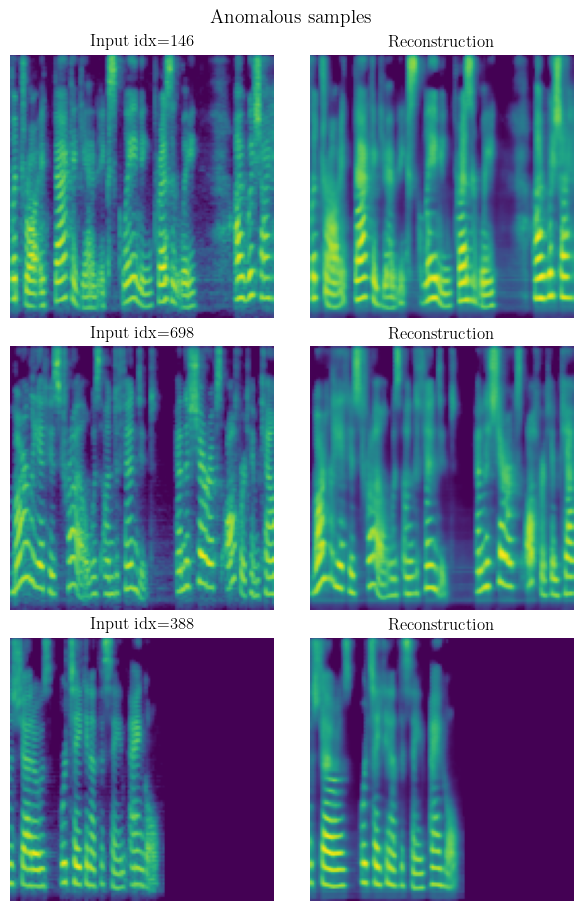

In [5]:
import argparse
import torch
from torch.utils.data import DataLoader
from RES_GANomaly_model import RES_Ganomaly

opt = build_parser().parse_args([])     # [] ⇒ no CLI → all defaults

opt.device  = "cuda:0"
opt.isize   = 128
opt.nc      = 1
opt.nz      = 100
opt.ngf     = 64
opt.ndf     = 128
opt.w_adv   = 1.0
opt.w_con   = 50.0
opt.w_enc   = 1.0
opt.manualseed = 1

dummy_ds = torch.utils.data.TensorDataset(torch.empty(1, 1, opt.isize, opt.isize))
dummy_loader = DataLoader(dummy_ds, batch_size=1)
dl_dict = {"train": [dummy_loader]}  

model = RES_Ganomaly(opt, dl_dict)        
ckpt_path = "/media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch2800.pth"
model.load(ckpt_path, strict=False)  
model.netg.eval()                    

test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/wavefake128_2048split/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# ----------------------------------------------------------------------
# 5) Run evaluation (uses only model.netg)
# ----------------------------------------------------------------------
scores, labels, a, b, c = evaluate_ganomaly(model.netg,
                                   test_loader,
                                   bona_label_value=0,  # fake = bona-fide
                                   device=opt.device)


[Init] Networks on cuda:0
NetG_RES_GANomaly: Calculated ngf_deepest for decoder: 1024
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch2800.pth (strict=False)


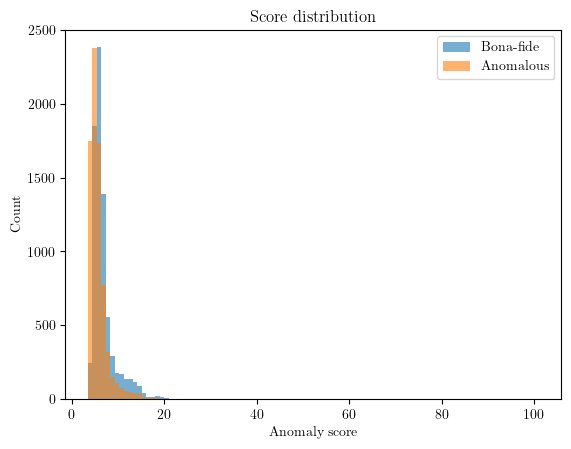

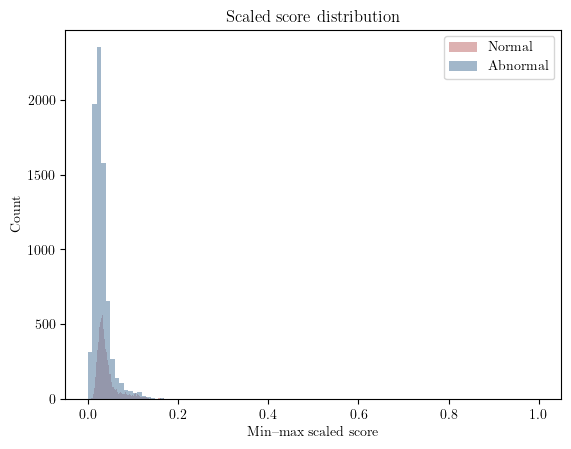

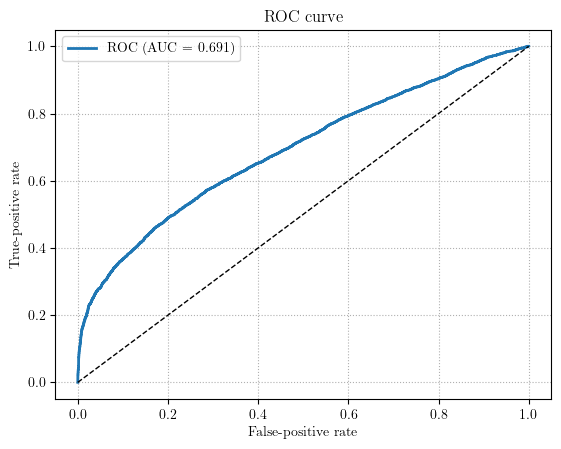

AUC          : 0.6912
Best F1      : 0.6729  @ thr ≤ 10.5646
Best Accuracy: 0.6448  @ thr ≤ 5.1996


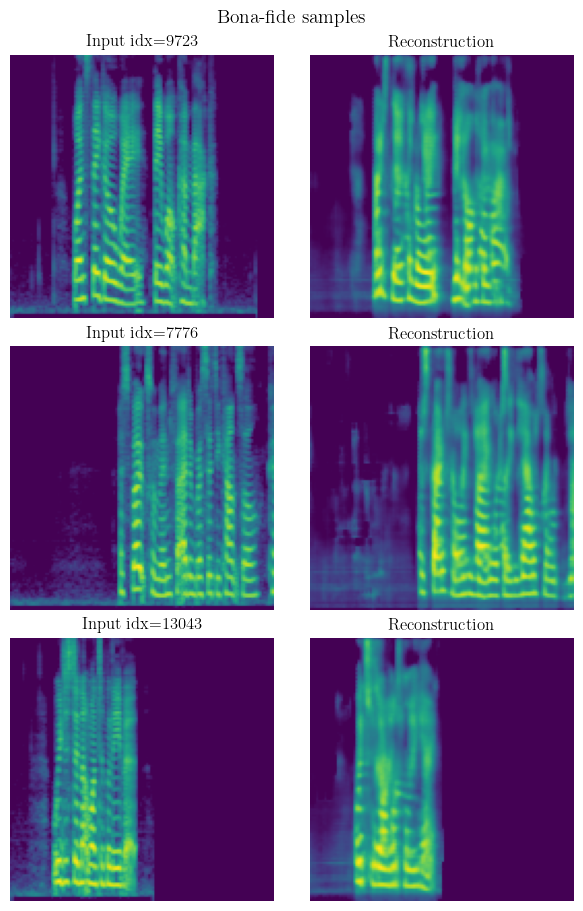

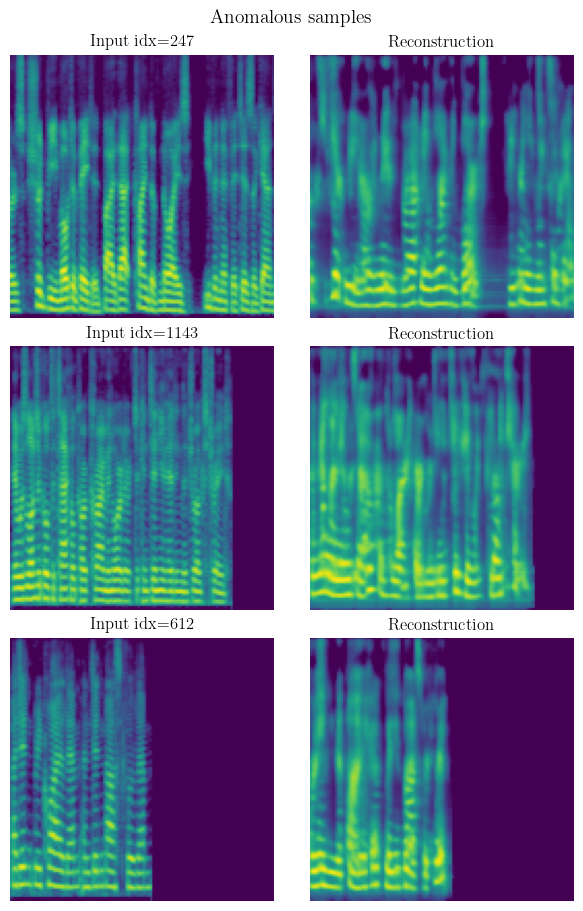

In [7]:
import argparse
import torch
from torch.utils.data import DataLoader
from RES_GANomaly_model import RES_Ganomaly

opt = build_parser().parse_args([])     # [] ⇒ no CLI → all defaults

opt.device  = "cuda:0"
opt.isize   = 128
opt.nc      = 1
opt.nz      = 100
opt.ngf     = 64
opt.ndf     = 128
opt.w_adv   = 1.0
opt.w_con   = 50.0
opt.w_enc   = 1.0
opt.manualseed = 1

dummy_ds = torch.utils.data.TensorDataset(torch.empty(1, 1, opt.isize, opt.isize))
dummy_loader = DataLoader(dummy_ds, batch_size=1)
dl_dict = {"train": [dummy_loader]}  

model = RES_Ganomaly(opt, dl_dict)        
ckpt_path = "/media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch2800.pth"
model.load(ckpt_path, strict=False)  
model.netg.eval()                    

test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/ASV128/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# ----------------------------------------------------------------------
# 5) Run evaluation (uses only model.netg)
# ----------------------------------------------------------------------
scores, labels, a, b, c = evaluate_ganomaly(model.netg,
                                   test_loader,
                                   bona_label_value=0,  # fake = bona-fide
                                   device=opt.device, lower_score_is_anomalous=True)


[Init] Networks on cuda:0
NetG_RES_GANomaly: Calculated ngf_deepest for decoder: 1024
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch10.pth (strict=False)
Epoch   10 → avg_real=39.820, avg_fake=37.509, F1=0.667@1302.897, ACC=0.510
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch20.pth (strict=False)
Epoch   20 → avg_real=39.732, avg_fake=37.298, F1=0.667@1174.930, ACC=0.515
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch30.pth (strict=False)
Epoch   30 → avg_real=13.392, avg_fake=14.506, F1=0.667@459.037, ACC=0.503
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints/checkpoint_epoch40.pth (strict=False)
Epoch   40 → avg_real=10.123, avg_fake=9.144, F

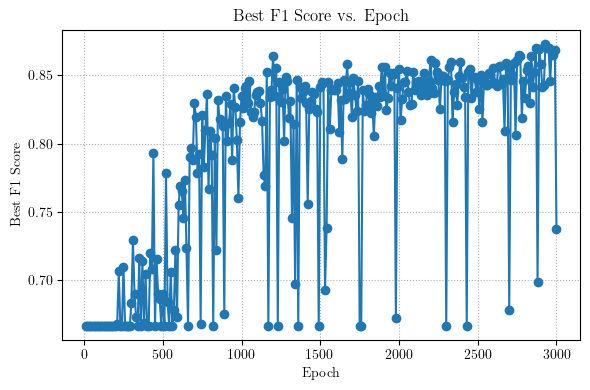

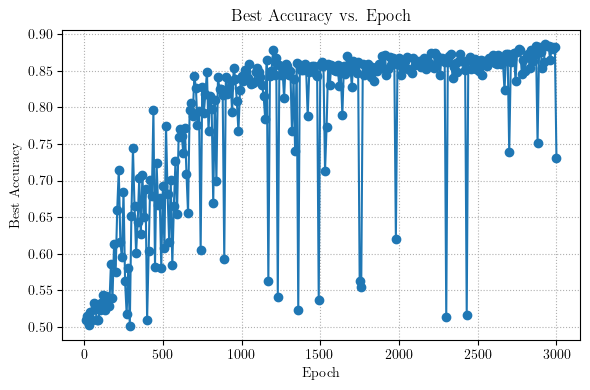

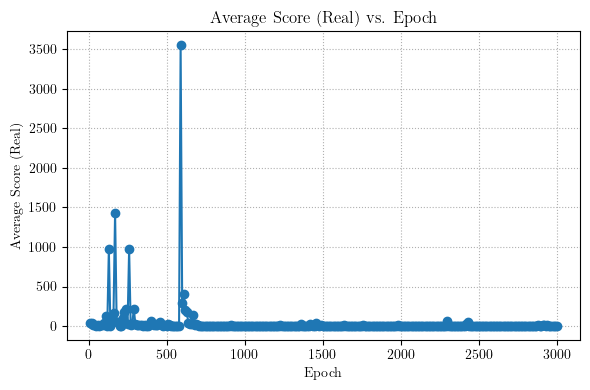

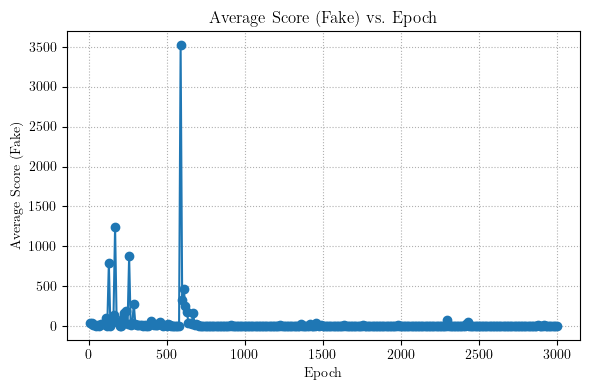

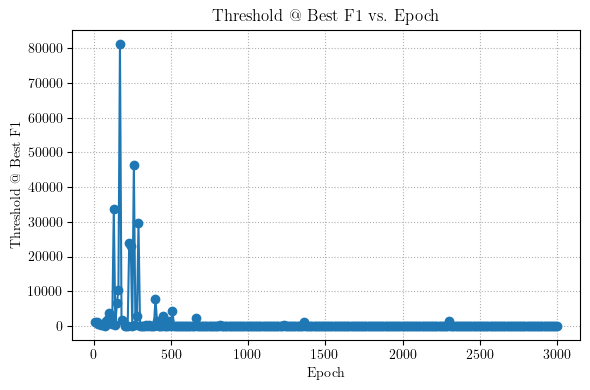

In [25]:
opt.device  = "cuda:0"
opt.isize   = 128
opt.nc      = 1
opt.nz      = 100
opt.ngf     = 64
opt.ndf     = 128
opt.w_adv   = 1.0
opt.w_con   = 50.0
opt.w_enc   = 1.0
opt.manualseed = 1

from torch.utils.data import DataLoader, TensorDataset
dummy_ds     = TensorDataset(torch.zeros(1, 1, opt.isize, opt.isize))
dummy_loader = DataLoader(dummy_ds, batch_size=1)
dl_dict      = {"train": [dummy_loader]}

model = RES_Ganomaly(opt, dl_dict)

test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/wavefake128_2048split/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_ds = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

metrics = evaluate_and_plot_epochs_efficient_model(
    model,
    test_loader,
    checkpoints_dir="/media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/FirstTime128/checkpoints",
    bona_label_value=0,             # or 1, whichever is your “normal” class
    device=opt.device,              # uses the exact same device you set above
    lower_score_is_anomalous=True
)

# Train ASV64 (real)

[Init] Networks on cuda:0
NetG_RES_GANomaly: Calculated ngf_deepest for decoder: 512
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints/checkpoint_epoch1900.pth (strict=False)
[Load] Will resume from epoch 1900


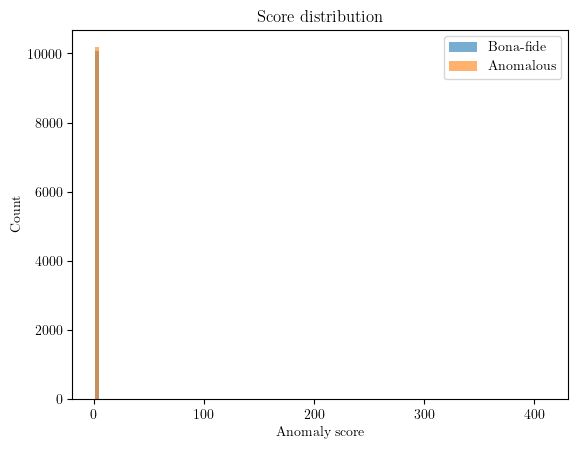

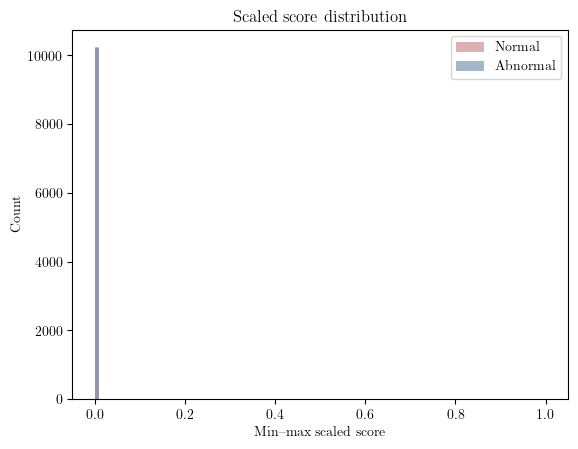

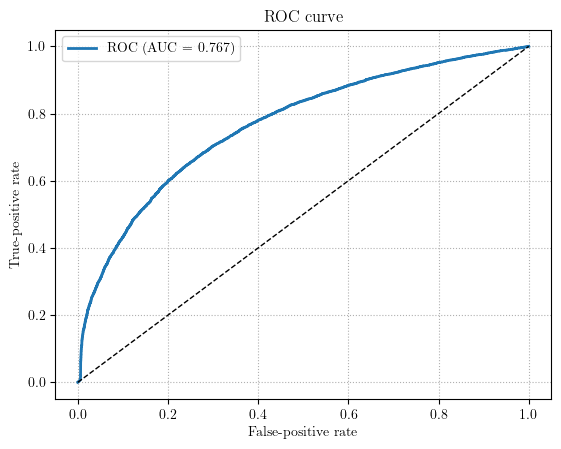

AUC          : 0.7669
Best F1      : 0.7186  @ thr ≥ 0.9992
Best Accuracy: 0.7026  @ thr ≥ 1.0680


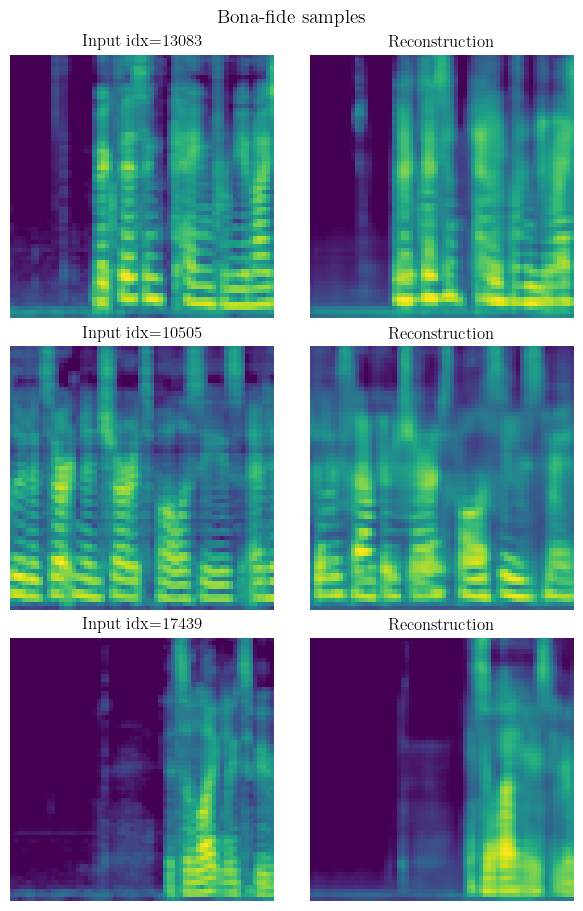

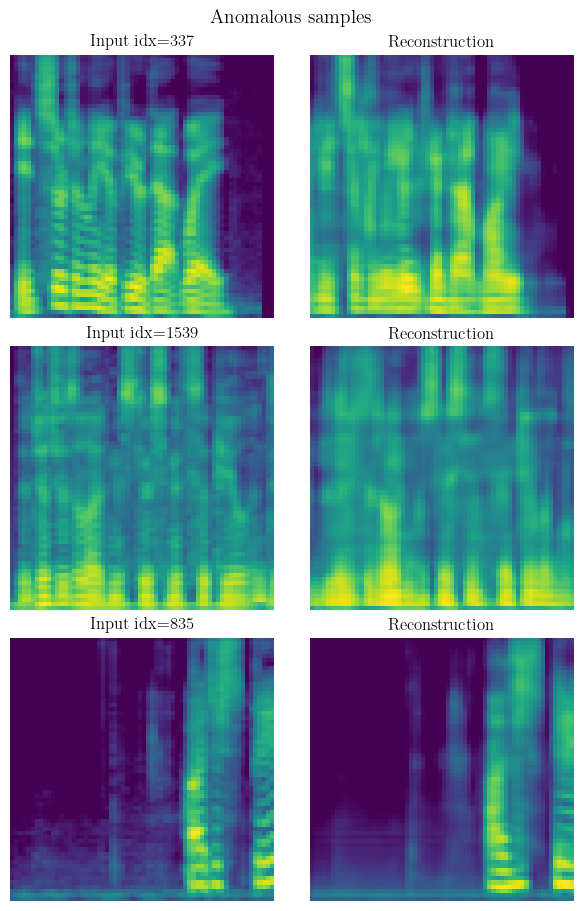

In [7]:
import argparse
import torch
from torch.utils.data import DataLoader
from RES_GANomaly_model import RES_Ganomaly

opt = build_parser().parse_args([])     # [] ⇒ no CLI → all defaults

opt.device  = "cuda:0"
opt.isize   = 64
opt.nc      = 1
opt.nz      = 100
opt.ngf     = 64
opt.ndf     = 128
opt.w_adv   = 1.0
opt.w_con   = 50.0
opt.w_enc   = 1.0
opt.manualseed = 1

dummy_ds = torch.utils.data.TensorDataset(torch.empty(1, 1, opt.isize, opt.isize))
dummy_loader = DataLoader(dummy_ds, batch_size=1)
dl_dict = {"train": [dummy_loader]}  

model = RES_Ganomaly(opt, dl_dict)        
ckpt_path = "/media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints/checkpoint_epoch1900.pth"
model.load(ckpt_path, strict=False)  
model.netg.eval()                    

test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/ASV64/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# ----------------------------------------------------------------------
# 5) Run evaluation (uses only model.netg)
# ----------------------------------------------------------------------
scores, labels, a, b, c = evaluate_ganomaly(model.netg,
                                   test_loader,
                                   bona_label_value=0,  # fake = bona-fide
                                   device=opt.device)


In [ ]:
opt.device  = "cuda:0"
opt.isize   = 64
opt.nc      = 1
opt.nz      = 100
opt.ngf     = 64
opt.ndf     = 128
opt.w_adv   = 1.0
opt.w_con   = 50.0
opt.w_enc   = 1.0
opt.manualseed = 1

from torch.utils.data import DataLoader, TensorDataset
dummy_ds     = TensorDataset(torch.zeros(1, 1, opt.isize, opt.isize))
dummy_loader = DataLoader(dummy_ds, batch_size=1)
dl_dict      = {"train": [dummy_loader]}

model = RES_Ganomaly(opt, dl_dict)

test_root = "/media/popsatorn/timeshift_backup/IMMC/ResData/ASV64/test/aggregated"    # directory containing fake.npy, real.npy
test_ds   = AggregatedPairDataset(test_root, isize=opt.isize)
test_ds = AggregatedPairDataset(test_root, isize=opt.isize)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

metrics = evaluate_and_plot_epochs_efficient_model(
    model,
    test_loader,
    checkpoints_dir="/media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints",
    bona_label_value=0,             # or 1, whichever is your “normal” class
    device=opt.device,              # uses the exact same device you set above
    lower_score_is_anomalous=True
)

[Init] Networks on cuda:0
NetG_RES_GANomaly: Calculated ngf_deepest for decoder: 512
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints/checkpoint_epoch10.pth (strict=False)
[Load] Will resume from epoch 10
Epoch   10 → avg_real=5.352, avg_fake=4.014, F1=0.676@7.041, ACC=0.536
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints/checkpoint_epoch20.pth (strict=False)
[Load] Will resume from epoch 20
Epoch   20 → avg_real=2.760, avg_fake=1.201, F1=0.676@1.677, ACC=0.665
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints/checkpoint_epoch30.pth (strict=False)
[Load] Will resume from epoch 30
Epoch   30 → avg_real=0.930, avg_fake=0.827, F1=0.671@1.484, ACC=0.591
[Load] netG/netD weights loaded from /media/popsatorn/timeshift_backup/IMMC/output_vanillaResGAN/ASV64/checkpoints/checkpoint_epoch40.pth (stric